# Tutorial 04 - Kriging, Cokriging & Kriging with Transformation

**Package:** stamps_v3  
**MATLAB equivalent:** `BMEHRLIBtutorial.m`  
**Dataset:** Falmagne soil dataset

---

## Learning objectives

1. Apply **ordinary kriging** of sand content on a 17 x 19 grid.
2. Apply **multivariate cokriging** jointly exploiting sand + silt + clay.
3. Apply **cokriging with transformation** (`cokrigingT`) using the Normal Score    Transform (NST) fitted in Tutorial 03.
4. Compare the three estimation strategies side-by-side.

### Key stamps_v3 functions

| Function | Module | Purpose |
|---|---|---|
| `kriging` | `stamps.stest.kriging` | Univariate OK/SK |
| `cokriging` | `stamps.stest.kriging` | Multivariate LMC cokriging |
| `cokrigingT` | `stamps.stest.kriging` | LMC cokriging + NST back-transform |


In [1]:
import sys, os, pickle
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from stamps.stamps.estimation.kriging import kriging, cokriging, cokrigingT
from stamps.stamps.graph.dataplot import plot_grid_map
from stamps.stamps.graph.categorical import plot_loocv

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

# --- Load dataset from Tutorial 01 ---
with open(os.path.join(DATA_DIR, 'tutorial01_data.pkl'), 'rb') as f:
    d1 = pickle.load(f)
ch   = d1['ch']
sand = d1['sand']
silt = d1['silt']
clay = d1['clay']
ck   = d1['ck']
n_e  = d1['n_e']
n_n  = d1['n_n']

# --- Load covariance / LMC parameters from Tutorial 03 ---
with open(os.path.join(DATA_DIR, 'tutorial03_cov.pkl'), 'rb') as f:
    cov = pickle.load(f)

sand_model  = cov['sand_covmodel']      # e.g. ['nuggetC', 'sphericalC']
sand_param  = cov['sand_covparam']      # [(c0,), (c1, a1)]
lmc_result  = cov['lmc_result']         # list of dicts from coregfit
z_sorted    = cov['sand_z_sorted']      # sorted original sand values
p_vals      = cov['sand_p_vals']        # corresponding CDF probabilities
nst_model   = cov['sand_nst_covmodel']  # e.g. ['nuggetC', 'sphericalC']
nst_param   = cov['sand_nst_covparam']  # parameters in NST space

print('Data:', ch.shape, '  Grid:', ck.shape)
print('Ordinary kriging model:', sand_model)


Data: (118, 2)   Grid: (323, 2)
Ordinary kriging model: ['nuggetC', 'sphericalC']


## 1. Ordinary kriging of sand content

Ordinary kriging (OK) minimises the estimation error variance subject to the unbiasedness constraint $\sum_\alpha \lambda_\alpha = 1$.  It relies only on the univariate covariance model of the target variable.


In [2]:
# Kriging neighbourhood parameters
nhmax = 25
dmax  = 10_000.0   # 10 km
order = 0          # ordinary kriging

print('Running ordinary kriging...')
zk_mean, zk_var = kriging(
    ck, ch, sand,
    sand_model, sand_param,
    nhmax, dmax, order
)
print(f'  Estimated nodes : {np.sum(~np.isnan(zk_mean))} / {len(ck)}')
print(f'  Mean estimate   : {np.nanmean(zk_mean):.2f}%')
print(f'  Mean variance   : {np.nanmean(zk_var):.4f}')


Running ordinary kriging...
  Estimated nodes : 323 / 323
  Mean estimate   : 14.72%
  Mean variance   : 71.3872


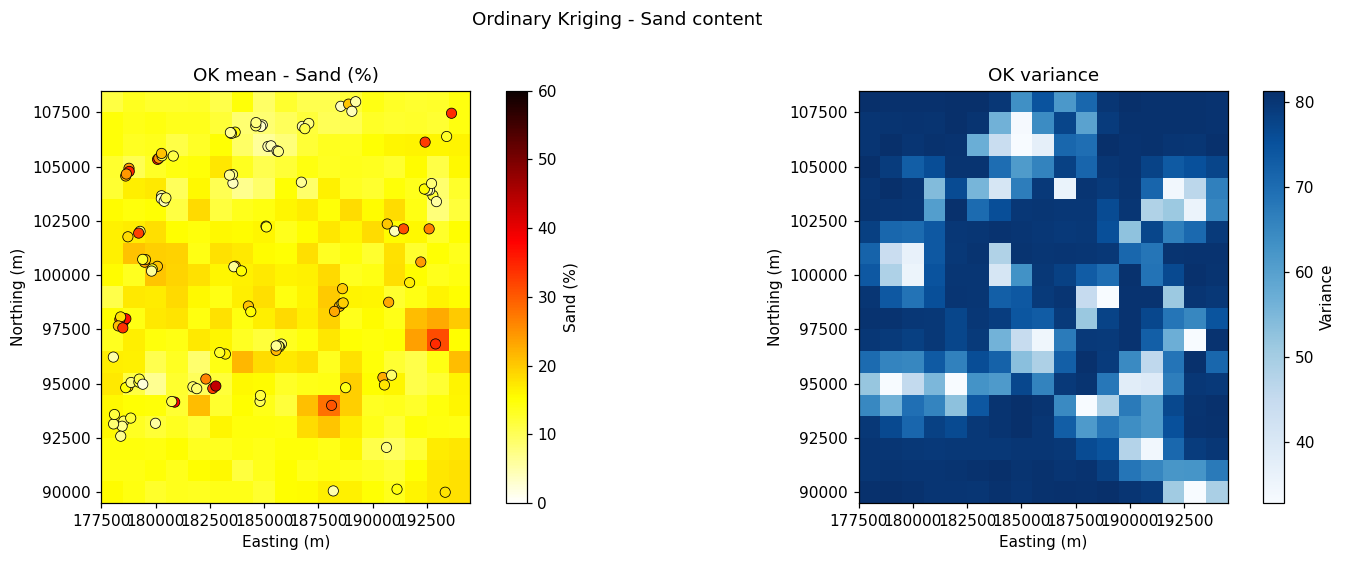

In [3]:
vlo, vhi = 0.0, 60.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_grid_map(axes[0], ck, zk_mean, 'OK mean - Sand (%)', n_e=n_e, n_n=n_n,
              ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
plot_grid_map(axes[1], ck, zk_var, 'OK variance', n_e=n_e, n_n=n_n,
              cmap='Blues', colorbar_label='Variance')
plt.suptitle('Ordinary Kriging - Sand content', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 2. Multivariate cokriging

Cokriging extends kriging to multiple co-regionalised variables.  All three soil fractions (sand, silt, clay) are jointly exploited using the **Linear Model of Coregionalization (LMC)** fitted in Tutorial 03.

The LMC cross-covariance between variable $i$ at lag $h$ is:

$$C_{ij}(h) = \sum_k B_k[i,j]\, g_k(h)$$

where $B_k$ are the sill matrices and $g_k$ are the basic spatial structures.

**stamps_v3 function:**
```python
zk_mean, zk_var = cokriging(
    ck, ck_var,    # estimation coords and variable indices
    ch, ch_var,    # data coords and variable indices
    zh,            # data values
    lmc_models,    # list of dicts from coregfit
    nhmax, dmax, order
)
```


In [4]:
n_pts = len(ch)

# Stack all three variables
ch_all  = np.vstack([ch, ch, ch])                    # (3n, 2)
zh_all  = np.concatenate([sand, silt, clay])          # (3n,)
var_all = np.concatenate([np.zeros(n_pts, dtype=int),  # 0 = sand
                           np.ones( n_pts, dtype=int),  # 1 = silt
                           2 * np.ones(n_pts, dtype=int)])  # 2 = clay

# All estimation locations target variable 0 (sand)
ck_var = np.zeros(len(ck), dtype=int)

print('LMC structures:')
for s in lmc_result:
    print(f'  {s["model"]}  sill matrix =\n{np.round(s["sill_matrix"], 2)}')

print('\nRunning cokriging...')
zk_cok_mean, zk_cok_var = cokriging(
    ck, ck_var,
    ch_all, var_all,
    zh_all,
    lmc_result,
    nhmax=15, dmax=10_000.0, order=0
)
print(f'  Estimated nodes : {np.sum(~np.isnan(zk_cok_mean))} / {len(ck)}')
print(f'  Mean variance   : {np.nanmean(zk_cok_var):.4f}')


LMC structures:
  nuggetC  sill matrix =
[[ 24.42 -21.21  -3.08]
 [-21.21  18.5    2.68]
 [ -3.08   2.68   0.43]]
  sphericalC  sill matrix =
[[ 46.52 -39.81  -6.66]
 [-39.81  79.91 -39.93]
 [ -6.66 -39.93  46.52]]

Running cokriging...
  Estimated nodes : 323 / 323
  Mean variance   : 72.0190


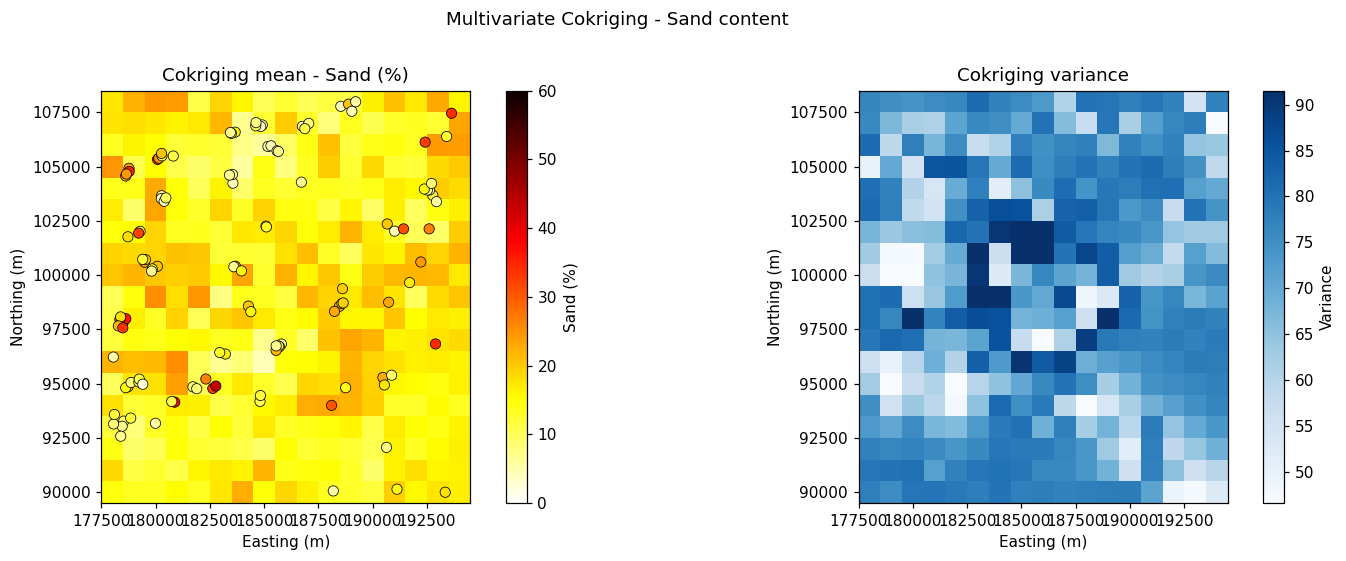

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_grid_map(axes[0], ck, zk_cok_mean, 'Cokriging mean - Sand (%)', n_e=n_e, n_n=n_n,
              ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
plot_grid_map(axes[1], ck, zk_cok_var, 'Cokriging variance', n_e=n_e, n_n=n_n,
              cmap='Blues', colorbar_label='Variance')
plt.suptitle('Multivariate Cokriging - Sand content', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 3. Cokriging with Normal Score Transformation (`cokrigingT`)

`cokrigingT` implements the full NST workflow automatically:

1. **Forward transform**: map each observation to Gaussian scores using the reference CDF.
2. **Cokriging**: estimate in the Gaussian-score space.
3. **Back-transformation**: convert the Gaussian posterior mean/variance back    to the original scale via numerical integration of the back-transformed density.

This is the recommended workflow when the marginal distribution is strongly non-Gaussian.

```python
zk_mean, zk_var = cokrigingT(
    ck, ck_var,
    ch, ch_var,
    yh,            # original (non-Gaussian) data
    lmc_models,    # LMC in NST space
    nhmax, dmax,
    yfiles,        # list of reference y-values per variable
    cdfy_files,    # list of reference CDF values per variable
    order
)
```


In [6]:
# For univariate NST kriging: use the single-variable LMC (nst_result)
# Build a 1-variable LMC from the univariate fitted NST parameters
from stamps.stamps.models.covmodel import nuggetC, sphericalC

def build_lmc_from_univariate(model_names, model_params):
    """Convert univariate model params to LMC format (1x1 sill matrices)."""
    lmc = []
    for name, param in zip(model_names, model_params):
        entry = {'model': name, 'sill_matrix': np.array([[param[0]]])}
        if len(param) > 1:
            rp = param[1]
            entry['range_param'] = float(np.asarray(rp).flat[0])
        lmc.append(entry)
    return lmc

nst_lmc = build_lmc_from_univariate(nst_model, nst_param)

print('NST LMC structures:')
for s in nst_lmc:
    print(f'  {s["model"]}  sill={s["sill_matrix"][0,0]:.3f}', end='')
    if 'range_param' in s:
        rp = s['range_param']
        rp_val = float(rp.flat[0]) if hasattr(rp, 'flat') else (float(rp[0]) if hasattr(rp, '__len__') else float(rp))
        print(f'  range={rp_val:.1f} m')
    else:
        print()

# All data are sand (variable 0), all estimation locations target sand (variable 0)
var_sand  = np.zeros(n_pts,      dtype=int)
ck_var_0  = np.zeros(len(ck),   dtype=int)

# Reference CDF lists (one per variable; here only one variable)
yfiles_list    = [z_sorted]   # reference y-values for variable 0 (sand)
cdfy_files_list = [p_vals]    # reference CDF for variable 0 (sand)

print('\nRunning cokrigingT (NST)...')
zk_nst_mean, zk_nst_var = cokrigingT(
    ck, ck_var_0,
    ch, var_sand,
    sand,          # original sand data (will be transformed internally)
    nst_lmc,
    nhmax=25, dmax=10_000.0,
    yfiles=yfiles_list,
    cdfy_files=cdfy_files_list,
    order=0
)
print(f'  Estimated nodes : {np.sum(~np.isnan(zk_nst_mean))} / {len(ck)}')
print(f'  Mean estimate   : {np.nanmean(zk_nst_mean):.2f}%')


NST LMC structures:
  nuggetC  sill=0.015
  sphericalC  sill=0.758  range=2937.4 m

Running cokrigingT (NST)...


  Estimated nodes : 323 / 323
  Mean estimate   : 14.71%


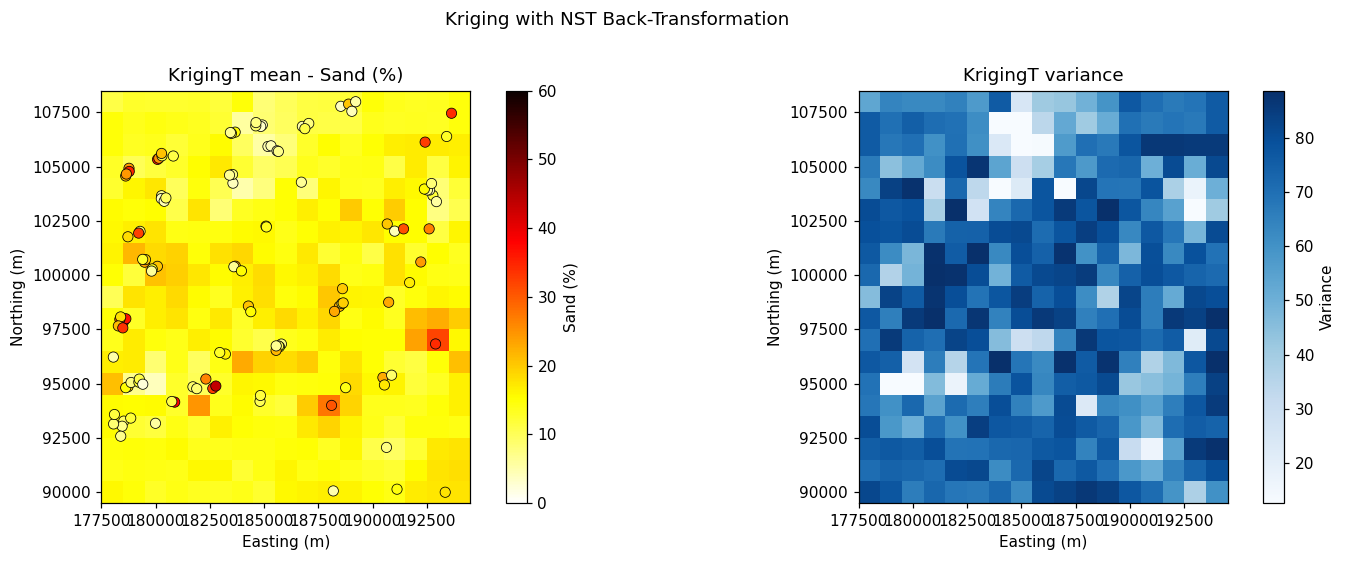

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_grid_map(axes[0], ck, zk_nst_mean, 'KrigingT mean - Sand (%)', n_e=n_e, n_n=n_n,
              ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
plot_grid_map(axes[1], ck, zk_nst_var, 'KrigingT variance', n_e=n_e, n_n=n_n,
              cmap='Blues', colorbar_label='Variance')
plt.suptitle('Kriging with NST Back-Transformation', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 4. Three-way comparison

Compare the mean estimate and estimation variance of the three methods.


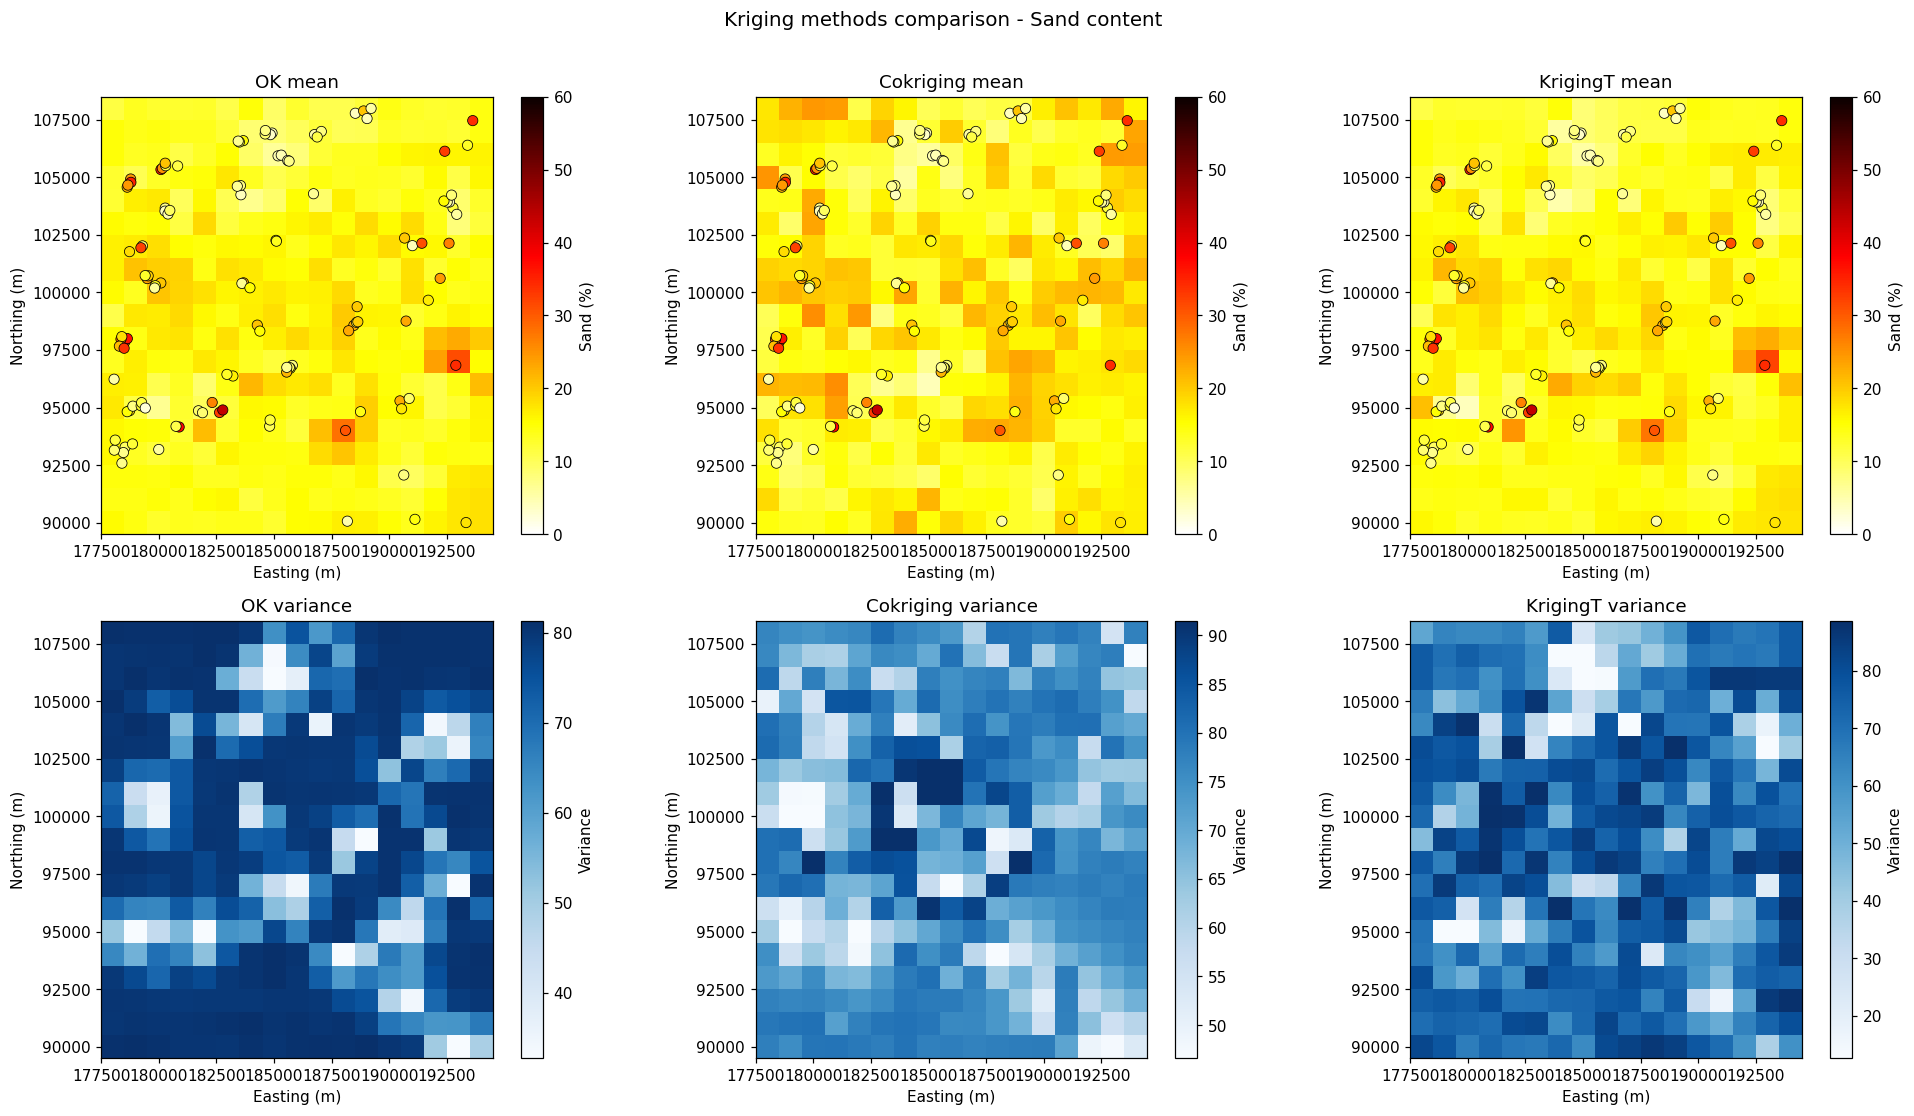

Mean estimation variance comparison:
  OK          : 71.3872
  Cokriging   : 72.0190
  KrigingT    : 66.2674


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

titles_mean = ['OK mean', 'Cokriging mean', 'KrigingT mean']
titles_var  = ['OK variance', 'Cokriging variance', 'KrigingT variance']
means = [zk_mean,     zk_cok_mean,  zk_nst_mean]
vars_ = [zk_var,      zk_cok_var,   zk_nst_var]

for i, (mu, va, tm, tv) in enumerate(zip(means, vars_, titles_mean, titles_var)):
    plot_grid_map(axes[0, i], ck, mu, tm, n_e=n_e, n_n=n_n,
                  ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')
    plot_grid_map(axes[1, i], ck, va, tv, n_e=n_e, n_n=n_n,
                  cmap='Blues', colorbar_label='Variance')

plt.suptitle('Kriging methods comparison - Sand content', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print('Mean estimation variance comparison:')
print(f'  OK          : {np.nanmean(zk_var):.4f}')
print(f'  Cokriging   : {np.nanmean(zk_cok_var):.4f}')
print(f'  KrigingT    : {np.nanmean(zk_nst_var):.4f}')


## 5. Neighbourhood sensitivity

Kriging results depend on the neighbourhood parameters `nhmax` and `dmax`.  A larger search radius includes more data but may incorporate points with very low spatial correlation.


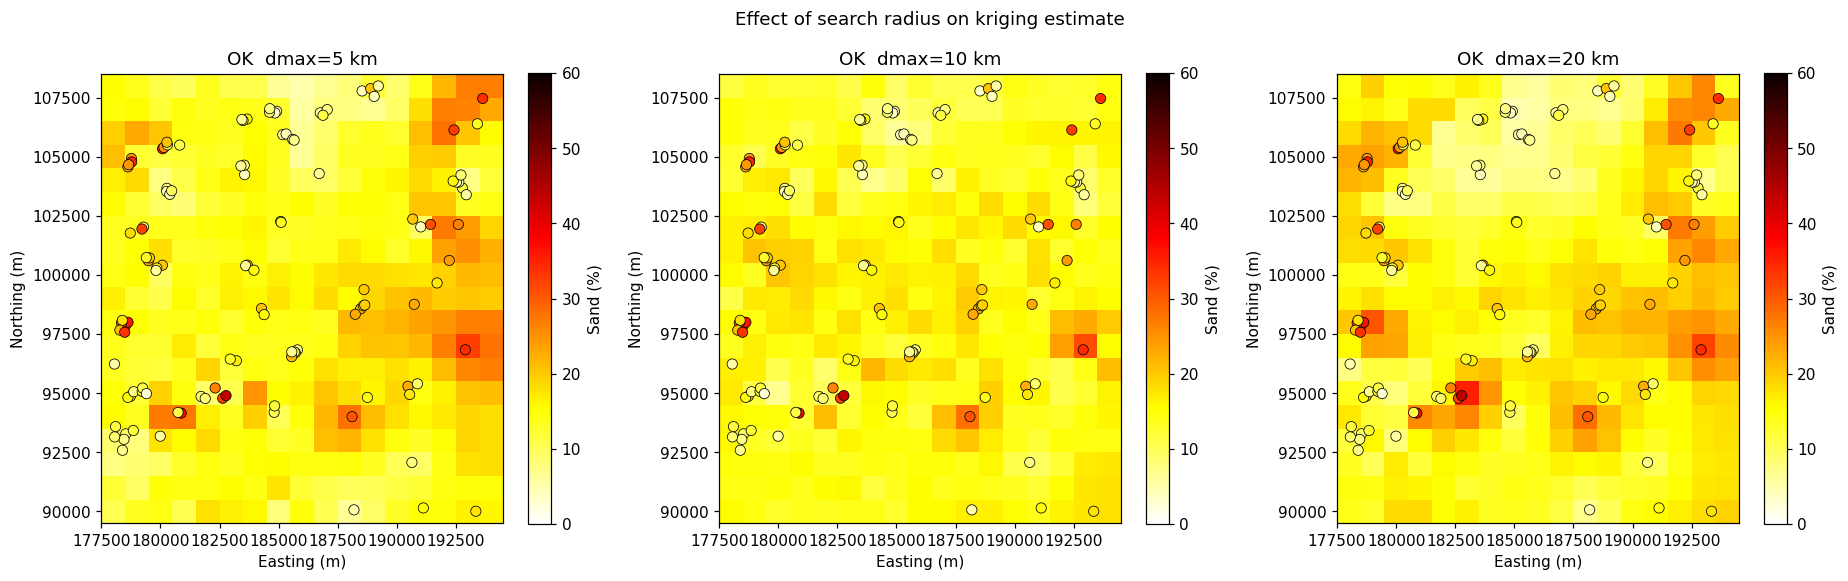

In [9]:
dmax_vals = [5_000, 10_000, 20_000]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, dv in zip(axes, dmax_vals):
    zk_m, zk_v = kriging(
        ck, ch, sand,
        sand_model, sand_param,
        nhmax=25, dmax=float(dv), order=0
    )
    plot_grid_map(ax, ck, zk_m, f'OK  dmax={dv//1000} km', n_e=n_e, n_n=n_n,
                  ch=ch, zh=sand, vmin=vlo, vmax=vhi, colorbar_label='Sand (%)')

plt.suptitle('Effect of search radius on kriging estimate', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 6. Leave-One-Out Cross-Validation (LOOCV)

Cross-validation is the gold standard for comparing spatial predictors when
an independent test set is not available.  For each of the **118 Falmagne
sample locations** we:

1. Remove that point from the calibration set.
2. Predict the sand content at that location with each of the three methods.
3. Record the prediction error `ê = predicted − observed`.

**Performance metrics**

| Symbol | Formula |
|--------|---------|
| RMSE   | √ mean(ê²) |
| MAE    | mean(|ê|) |
| Bias   | mean(ê) |
| R²     | 1 − Σê² / Σ(obs − obs̄)² |

A lower RMSE / higher R² indicates a better predictor.

In [10]:
import time

n_pts = len(ch)
cv_ok  = np.full(n_pts, np.nan)
cv_cok = np.full(n_pts, np.nan)
cv_nst = np.full(n_pts, np.nan)

t0 = time.time()
print(f'Leave-one-out CV over {n_pts} points …')

for i in range(n_pts):
    mask = np.ones(n_pts, dtype=bool); mask[i] = False
    ci   = ch[i:i+1]   # (1, 2) – single estimation target

    # ── Ordinary Kriging ──────────────────────────────────────────────
    _zm, _ = kriging(ci, ch[mask], sand[mask],
                     sand_model, sand_param,
                     nhmax, dmax, order=0)
    cv_ok[i] = float(np.asarray(_zm).flat[0])

    # ── Cokriging ─────────────────────────────────────────────────────
    # Remove point i from all three variable stacks (sand / silt / clay)
    mask_all = np.ones(3 * n_pts, dtype=bool)
    mask_all[i]             = False   # sand_i
    mask_all[n_pts + i]     = False   # silt_i
    mask_all[2 * n_pts + i] = False   # clay_i
    _zm2, _ = cokriging(ci, np.array([0]),
                         ch_all[mask_all], var_all[mask_all], zh_all[mask_all],
                         lmc_result, nhmax=15, dmax=10_000.0, order=0)
    cv_cok[i] = float(np.asarray(_zm2).flat[0])

    # ── KrigingT (NST) ────────────────────────────────────────────────
    _zm3, _ = cokrigingT(ci, np.array([0]),
                          ch[mask], np.zeros(n_pts - 1, dtype=int), sand[mask],
                          nst_lmc, nhmax=25, dmax=10_000.0,
                          yfiles=yfiles_list, cdfy_files=cdfy_files_list, order=0)
    cv_nst[i] = float(np.asarray(_zm3).flat[0])

    if (i + 1) % 25 == 0 or i == n_pts - 1:
        print(f'  {i+1:>3}/{n_pts}  ({time.time()-t0:.1f}s elapsed)')

print(f'\nFinished in {time.time()-t0:.1f}s')

Leave-one-out CV over 118 points …
   25/118  (0.1s elapsed)
   50/118  (0.2s elapsed)


   75/118  (0.3s elapsed)
  100/118  (0.3s elapsed)
  118/118  (0.4s elapsed)

Finished in 0.4s


Method                    N   RMSE (%)   MAE (%)  Bias (%)      R²
------------------------------------------------------------------
Ordinary Kriging        118     10.149     7.924    -1.151 -0.1383
Cokriging               118     10.733     8.712    -0.550 -0.2731
KrigingT (NST)          118     10.086     7.904    -1.370 -0.1242


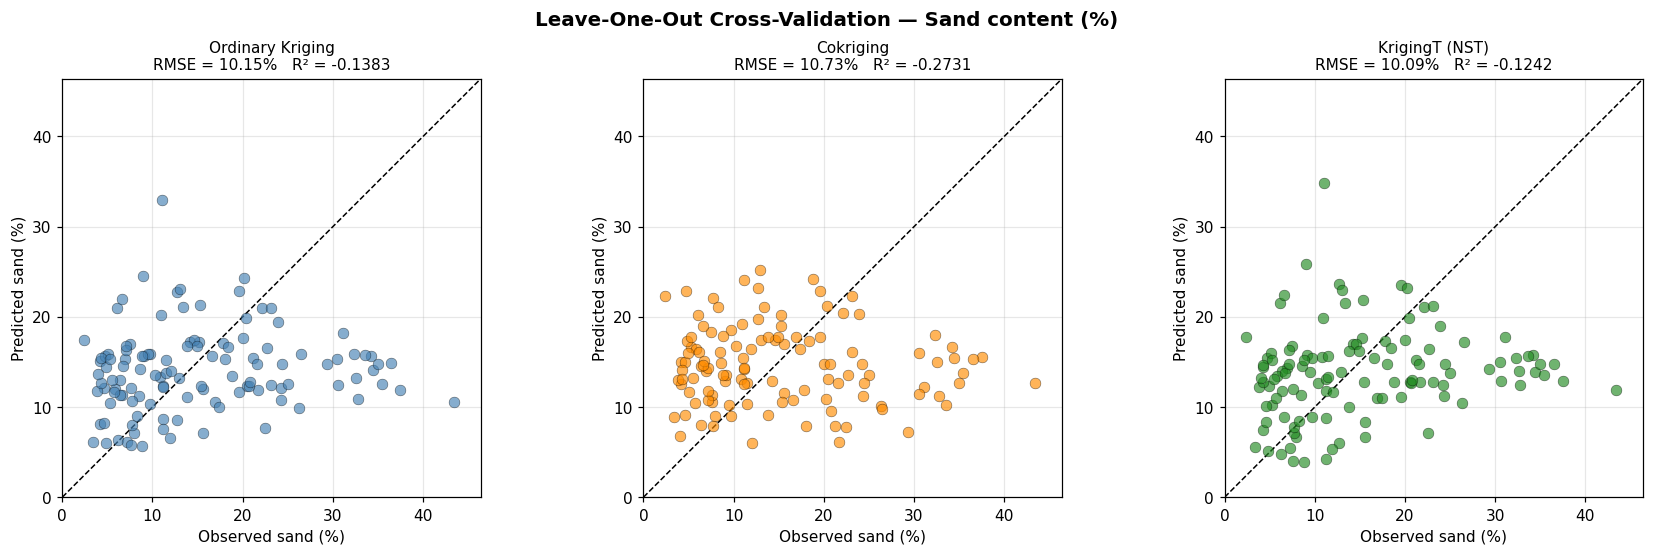

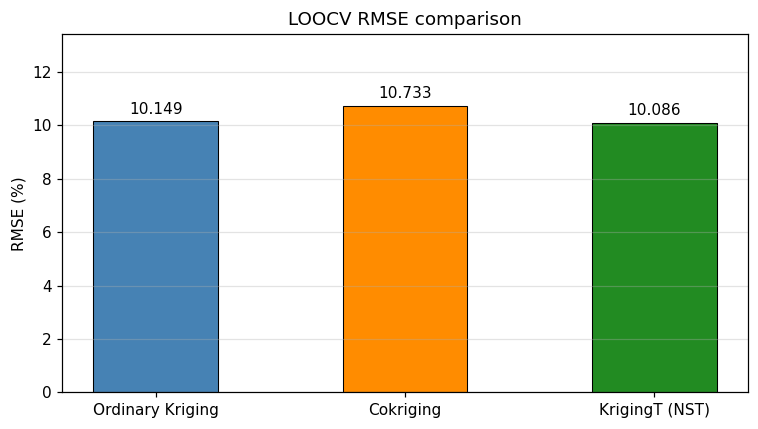

In [11]:
# ── Performance metrics ──────────────────────────────────────────────────
def cv_metrics(obs, pred, name):
    valid = ~np.isnan(pred)
    res   = pred[valid] - obs[valid]
    rmse  = np.sqrt(np.mean(res**2))
    mae   = np.mean(np.abs(res))
    bias  = np.mean(res)
    ss_res = np.sum(res**2)
    ss_tot = np.sum((obs[valid] - obs[valid].mean())**2)
    r2    = 1.0 - ss_res / ss_tot
    return dict(Method=name, N=int(valid.sum()),
                RMSE=rmse, MAE=mae, Bias=bias, R2=r2)

rows = [
    cv_metrics(sand, cv_ok,  'Ordinary Kriging'),
    cv_metrics(sand, cv_cok, 'Cokriging'),
    cv_metrics(sand, cv_nst, 'KrigingT (NST)'),
]

header = f"{'Method':<22} {'N':>4} {'RMSE (%)':>10} {'MAE (%)':>9} {'Bias (%)':>9} {'R\u00b2':>7}"
print(header)
print('-' * len(header))
for r in rows:
    print(f"{r['Method']:<22} {r['N']:>4} {r['RMSE']:>10.3f} {r['MAE']:>9.3f} {r['Bias']:>9.3f} {r['R2']:>7.4f}")

# ── Scatter + RMSE bar chart using plot_loocv ────────────────────────────
method_names = [r['Method'] for r in rows]
pred_list    = [cv_ok, cv_cok, cv_nst]
metrics_dict = {
    'RMSE (%)': [r['RMSE'] for r in rows],
    'MAE (%)':  [r['MAE']  for r in rows],
    'R\u00b2':  [r['R2']   for r in rows],
}

fig, axes = plot_loocv(
    method_names,
    obs=sand, pred_list=pred_list,
    metrics=metrics_dict,
    unit='%',
    suptitle='Leave-One-Out CV \u2014 Sand content (%)',
    colors=['steelblue', 'darkorange', 'forestgreen'],
)
plt.show()


In [12]:
# Save results for Tutorial 05
import pickle

krig_results = {
    'zk_ok_mean':  zk_mean,
    'zk_ok_var':   zk_var,
    'zk_cok_mean': zk_cok_mean,
    'zk_cok_var':  zk_cok_var,
    'zk_nst_mean': zk_nst_mean,
    'zk_nst_var':  zk_nst_var,
}
save_path = os.path.join(DATA_DIR, 'tutorial04_krig.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(krig_results, f)
print('Saved:', save_path)


Saved: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data/tutorial04_krig.pkl


## 6. Summary

| Method | Variables used | Notes |
|---|---|---|
| Ordinary Kriging | Sand only | Baseline, assumes Gaussian distribution |
| Cokriging | Sand + Silt + Clay | Exploits cross-correlations (LMC) |
| KrigingT | Sand (via NST) | Handles non-Gaussian marginals correctly |

**Key insights:**
- Cokriging reduces estimation variance when auxiliary variables are correlated with the target.
- `cokrigingT` is preferred when the marginal distribution is significantly non-Gaussian.
- For weakly correlated auxiliary variables, cokriging converges to ordinary kriging.

**Next:** Tutorial 05 - BME with interval (soft) data.
